In [1]:
# Get the necessary packages

!pip install esm
!pip install peft
!pip install bitsandbytes

from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig
import torch
import torch.nn as nn
from esm.tokenization import EsmSequenceTokenizer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from peft import LoraConfig, get_peft_model
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import bitsandbytes as bnb
from tqdm import tqdm
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.7/302.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.5 M

In [2]:
# Set the random seeds
torch.manual_seed(40)
torch.cuda.manual_seed(40)

In [4]:
## Load and preprocess the data into train and test sets

def read_fasta(file_path):
    '''Read a FASTA file and return a list of sequences.'''
    sequences=[]
    current_sequence=[]
    with open(file_path,"r") as file:
        for line in file:
            if line.startswith(">"):
                if current_sequence:
                    sequences.append(''.join(current_sequence))
                    current_sequence=[]
            else:
                current_sequence.append(line.strip())
        if current_sequence:
            sequences.append(''.join(current_sequence))
    return sequences

# Read the sequences from the FASTA files and create DataFrames for each dataset

sequences_do = read_fasta("mobidb_do_cdhit.fasta")
sequences_dd = read_fasta("mobidb_dd_cdhit.fasta")


df_do = pd.DataFrame(sequences_do, columns=["sequence"])
df_do["label"] = 0
df_dd = pd.DataFrame(sequences_dd, columns=["sequence"])
df_dd["label"] = 1


# Calculate the length of each sequence and add it as a new column

df_do["length"] = df_do["sequence"].apply(len)
df_dd["length"] = df_dd["sequence"].apply(len)

print("mobidb_do:",df_do["length"].describe(), sep="\n")
print("mobidb_dd:",df_dd["length"].describe(), sep="\n")

# Concatenate the DataFrames

df_all = pd.concat([df_do, df_dd], ignore_index=True)

# Filter out sequences longer than 1000 characters

print("Number of removed sequences:" ,df_all[df_all["length"] > 1000]["sequence"].count())
df_all = df_all[df_all["length"] < 1001]

# Remove all sequences that are repeated more than once

sequence_counts = df_all["sequence"].value_counts()
unique_sequences = sequence_counts[sequence_counts == 1].index
df_unique = df_all[df_all["sequence"].isin(unique_sequences)].reset_index(drop=True)
print("Unique sequences count:", df_unique.shape[0])

# Split the dataset into training and testing sets, stratifying by label

train_df, test_df = train_test_split(df_unique, test_size=0.30, stratify=df_unique["label"], random_state=40, shuffle=True)

print("Train set size:", train_df.shape[0])
print("Test set size:", test_df.shape[0])
print("Train set label distribution:\n", train_df["label"].value_counts())
print("Test set label distribution:\n", test_df["label"].value_counts())
print("Train set length distribution:\n", train_df["length"].describe())
print("Test set length distribution:\n", test_df["length"].describe())
print("Columns in train set and test set:", train_df.columns.tolist(), test_df.columns.tolist())


mobidb_do:
count    11673.000000
mean        47.345327
std         94.411344
min         11.000000
25%         14.000000
50%         20.000000
75%         41.000000
max       3768.000000
Name: length, dtype: float64
mobidb_dd:
count    21059.000000
mean        51.388432
std        107.135028
min         11.000000
25%         16.000000
50%         24.000000
75%         47.000000
max       3421.000000
Name: length, dtype: float64
Number of removed sequences: 49
Unique sequences count: 32607
Train set size: 22824
Test set size: 9783
Train set label distribution:
 label
1    14687
0     8137
Name: count, dtype: int64
Test set label distribution:
 label
1    6295
0    3488
Name: count, dtype: int64
Train set length distribution:
 count    22824.000000
mean        47.808141
std         75.411392
min         11.000000
25%         15.000000
50%         23.000000
75%         45.000000
max        999.000000
Name: length, dtype: float64
Test set length distribution:
 count    9783.000000
mean    

In [5]:
## Tokenize the sequences

# Shuffle train_df
train_df = train_df.sample(frac=1, random_state=42)

# Reset the index of the shuffled DataFrame
train_df = train_df.reset_index(drop=True)

# Instantiate the tokenizer
tokenizer = EsmSequenceTokenizer()

# Pre-tokenize all sequences in the dataframe
train_df["tokenized_sequence"] = train_df["sequence"].apply(lambda seq: tokenizer(seq, return_tensors="pt"))
test_df["tokenized_sequence"] = test_df["sequence"].apply(lambda seq: tokenizer(seq, return_tensors="pt"))

# Define a PyTorch Dataset class for the sequences
class SequenceDataset(Dataset):
    """Custom PyTorch Dataset for protein sequences."""
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):
        row = self.df.iloc[idx]
        sequence = row["sequence"]
        label = row["label"]
        # Use  the pre-tokenized sequence
        sequence_tensor = row["tokenized_sequence"]
        label_tensor = torch.tensor(row["label"], dtype=torch.long)
        return sequence_tensor, label_tensor

# Define a custom collate function to handle padding
def collate_fn(batch):
    """
    Collate function to pad sequences within a batch.
    """
    # batch is a list of tuples: [(sequence_tensor_1, label_tensor_1), (sequence_tensor_2, label_tensor_2), ...]
    sequences = [item[0] for item in batch]
    labels = torch.stack([item[1] for item in batch])

    # Pad the sequences to the maximum length in the batch
    # tokenizer returns a dictionary with 'input_ids' and 'attention_mask'
    input_ids = [seq['input_ids'].squeeze(0) for seq in sequences] # Remove the batch dimension from the tokenizer output
    attention_masks = [seq['attention_mask'].squeeze(0) for seq in sequences]

    # Pad input_ids and attention_masks
    padded_input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    padded_attention_masks = torch.nn.utils.rnn.pad_sequence(attention_masks, batch_first=True, padding_value=0) # Padding value for attention mask is 0

    # Recreate the dictionary structure expected by the model
    padded_sequences = {'input_ids': padded_input_ids, 'attention_mask': padded_attention_masks}

    return padded_sequences, labels


In [6]:
# Functions for training and testing the Pytorch model

def train_step(model, dataloader, loss_fn, optimizer, device, accumulation_steps=1):
    ''' Trains a Pytorch model for a single epoch.
    Args:
        model: A PyTorch model to be trained.
        dataloader: A DataLoader instance for the model to be trained on.
        loss_fn: A PyTorch loss function to minimize.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        device: A target device to compute on (e.g. "cuda" or "cpu").
        accumulation_steps: The number of steps to accumulate gradients over.
                            Default is 1 (no accumulation).
    Returns:
        A tuple of training loss and training accuracy metrics.
    '''

    # Put model in train mode
    model.train()

    # Set train loss and train accuracy values
    train_loss, train_accuracy = 0, 0

    # Loop through data loader
    for batch, (sequence, labels) in enumerate(tqdm(dataloader,desc="Processing batches for training")):
        # Move sequence tensors and labels to the device
        sequence = {key: val.to(device) for key, val in sequence.items()}
        label = labels.to(device)


        # Forward pass
        pred_logits = model(sequence)
        # Calculate loss and normalize for accumulation
        loss = loss_fn(pred_logits, label)

        # If performing gradient accumulation, normalize the loss
        if accumulation_steps > 1:
            loss = loss / accumulation_steps

        # Backward pass
        loss.backward()


        # Perform optimizer step and zero gradients only after accumulation_steps
        if (batch + 1) % accumulation_steps == 0 or (batch + 1) == len(dataloader):
            optimizer.step()
            optimizer.zero_grad()

        # Accumulate total loss before normalization
        train_loss += loss.item()

        # Calculate and accumulate metric across all batches
        pred_label = pred_logits.argmax(dim=1)
        train_accuracy += (pred_label == label).sum().item()/len(pred_logits)

    # Get average metrics per batch
    train_loss = train_loss / len(dataloader)
    train_accuracy = train_accuracy / len(dataloader)
    return train_loss, train_accuracy

def test_step(model, dataloader, loss_fn, device):
    """Tests a PyTorch model for a single epoch.
    Args:
        model: A PyTorch model to be tested.
        dataloader: A DataLoader instance for the model to be tested on.
        loss_fn: A PyTorch loss function to calculate loss on the test data.
        device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
        A tuple of testing loss, testing accuracy, f1 score, precision, recall, and confusion matrix.
    """

    # Put model in eval mode
    model.eval()

    # Set test loss and test accuracy values
    test_loss, test_accuracy = 0, 0
    # Create lists for label and predicted label across all batch
    label_batch = []
    pred_label_batch = []

    with torch.inference_mode():
        # Loop through dataloader batches
        for batch, (sequence, labels) in enumerate(tqdm(dataloader, desc="Processing batches for testing")):
            # Move sequence tensors and labels to the device
            sequence = {key: val.to(device) for key, val in sequence.items()}
            label = labels.to(device)

            # Foward pass
            test_pred_logits = model(sequence)

            # Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, label)
            test_loss += loss.item()

            # Calculate and accumulate metric across all batches
            test_pred_labels = test_pred_logits.argmax(dim=1)
            label_batch += label.tolist()
            pred_label_batch += test_pred_labels.tolist()
            test_accuracy += (test_pred_labels == label).sum().item()/len(test_pred_labels)

    # Get average metrics per patch
    test_loss = test_loss / len(dataloader)
    test_accuracy = test_accuracy / len(dataloader)
    f1 = f1_score(np.array(label_batch), np.array(pred_label_batch), average="weighted")
    precision = precision_score(np.array(label_batch), np.array(pred_label_batch), average="weighted")
    recall = recall_score(np.array(label_batch), np.array(pred_label_batch), average="weighted")
    conf_matrix = confusion_matrix(np.array(label_batch), np.array(pred_label_batch))
    return test_loss, test_accuracy, f1, precision, recall, conf_matrix

In [7]:
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs, device, accumulation_steps=1):
  """Trains and tests a PyTorch model.

    Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    accumulation_steps: The number of steps to accumulate gradients over.
                            Default is 1 (no accumulation).

    Returns:
    A dictionary of training and testing loss as well as training and
    testing metrics. Each metric has a value in a list for each epoch.
    """

  results ={
      "train_loss": [],
      "train_accuracy": [],
      "test_loss": [],
      "test_accuracy": [],
      "test_f1": [],
      "test_precision": [],
      "test_recall": [],
      "test_confusion_matrix": []
  }

  # Set model type as float32 and transfer to device
  model.to(torch.float32).to(device)

  # Loop through training and testing steps for a number of epochs
  for epoch in range(epochs):
    train_loss, train_accuracy = train_step(model=model,
                                            dataloader=train_dataloader,
                                            loss_fn=loss_fn,
                                            optimizer=optimizer,
                                            device=device,
                                            accumulation_steps=accumulation_steps)
    test_loss, test_accuracy, f1, precision, recall, conf_matrix = test_step(model=model,
                                                                            dataloader=test_dataloader,
                                                                            loss_fn=loss_fn,
                                                                            device=device)

    # Update results dictionary
    results["train_loss"].append(train_loss)
    results["train_accuracy"].append(train_accuracy)
    results["test_loss"].append(test_loss)
    results["test_accuracy"].append(test_accuracy)
    results["test_f1"].append(f1)
    results["test_precision"].append(precision)
    results["test_recall"].append(recall)
    results["test_confusion_matrix"].append(conf_matrix)

    # Display results after each epoch
    epoch_results_df = pd.DataFrame({
        "Epoch": [epoch + 1],
        "train_loss": [train_loss],
        "train_accuracy": [train_accuracy],
        "test_loss": [test_loss],
        "test_accuracy": [test_accuracy],
        "test_f1": [f1],
        "test_precision": [precision],
        "test_recall": [recall],
        "test_confusion_matrix": [conf_matrix]
    })
    display(epoch_results_df)

  # Return the results at the end of the epochs
  return results

In [8]:
# Define  modified ESMC model for protein sequence classification

class ESMC_SequenceClassification(nn.Module):
    '''ESMC model for sequence classification tasks.
    Args:
        num_labels (int): Number of output labels for classification.
        model (ESMC): Pretrained ESMC model instance.
        num_features (int): Dimensionality of the model's output features
        dropout (float): Dropout rate for regularization.
    '''
    def __init__(self, num_labels, model, num_features, dropout=0.0):
        super(ESMC_SequenceClassification, self).__init__()
        self.num_labels = num_labels
        self.model = model
        self.dropout = dropout
        self.num_features = num_features
        self.classification_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_labels),
            )


    # Modify forward to accept input_ids and attention_mask
    def forward(self, encoded_inputs):
        # Pass input_ids and attention_mask to the base ESM model's standard forward.
        attention_mask = None
        try:
            input_ids = encoded_inputs['input_ids']
            attention_mask = encoded_inputs['attention_mask']
        except KeyError:
             # If encoded_inputs is not a dictionary, assume it's just input_ids
             input_ids = encoded_inputs
             attention_mask = None # Set attention_mask to None if not provided

        # Pass input_ids and attention_mask to the underlying model
        outputs = self.model(sequence_tokens=input_ids, sequence_id=attention_mask)


        # Use mean pooling of the embeddings for sequence-level representation
        # outputs.embeddings will have shape (batch_size, sequence_length, hidden_size)
        # Apply attention mask during pooling
        if attention_mask is not None:
            # Mask out padding tokens before averaging
            masked_embeddings = outputs.embeddings * attention_mask.unsqueeze(-1)
            sum_embeddings = masked_embeddings.sum(dim=1)
            num_non_padded_tokens = attention_mask.sum(dim=1).unsqueeze(-1)
            # Avoid division by zero if a sequence is all padding
            num_non_padded_tokens = torch.max(num_non_padded_tokens, torch.ones_like(num_non_padded_tokens))
            pooled_output = sum_embeddings / num_non_padded_tokens
        else:
            pooled_output = outputs.embeddings.mean(dim=1) # Fallback if no attention mask

        logits = self.classification_head(pooled_output)
        return logits

In [9]:
# Function to get percentage of trainable parameters
def print_trainable_parameters(model):
    trainable_params, all_param = 0, 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param:.2f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

Processing batches for testing: 100%|██████████| 1223/1223 [10:05<00:00,  2.02it/s]


,Epoch,train_loss,train_accuracy,test_loss,test_accuracy,test_f1,test_precision,test_recall,test_confusion_matrix
0,4,0.650814,0.689932,0.644837,0.703276,0.706003,0.710385,0.703261,"[[2204, 1284], [1619, 4676]]"


Processing batches for testing: 100%|██████████| 1223/1223 [10:05<00:00,  2.02it/s]


,Epoch,train_loss,train_accuracy,test_loss,test_accuracy,test_f1,test_precision,test_recall,test_confusion_matrix
0,5,0.642316,0.690457,0.636747,0.700926,0.704657,0.711854,0.70091,"[[2269, 1219], [1707, 4588]]"


Confusion matrix for epoch 0:


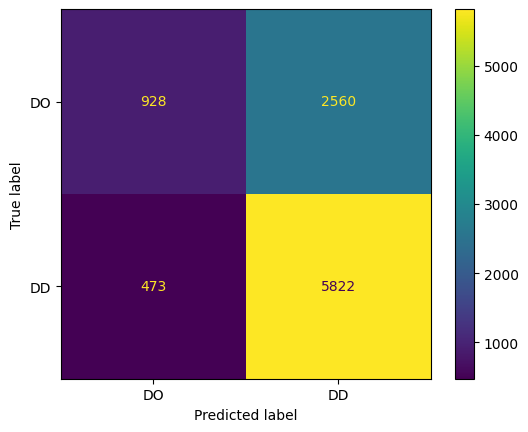

Confusion matrix for epoch 1:


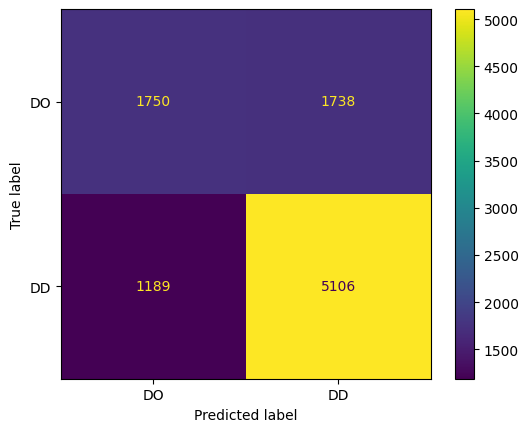

Confusion matrix for epoch 2:


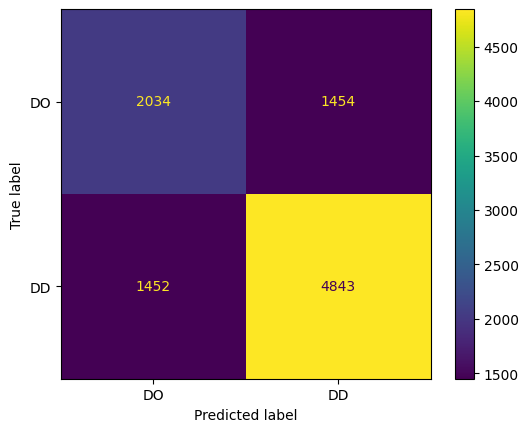

Confusion matrix for epoch 3:


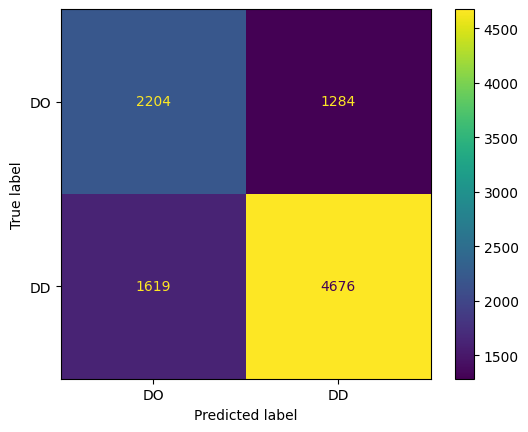

Confusion matrix for epoch 4:


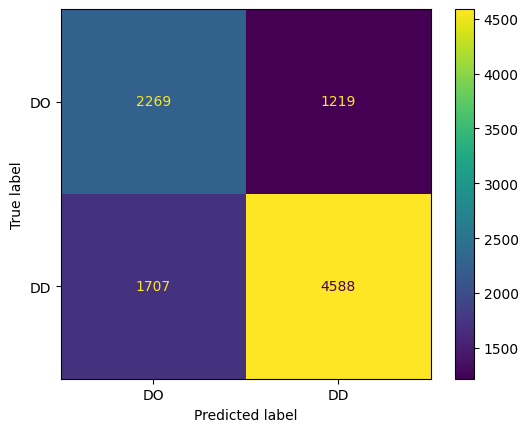

In [ ]:
## Transfer learning for classification without fine tuning

# Create datasets for training and testing
train_dataset = SequenceDataset(train_df)
test_dataset = SequenceDataset(test_df)

# Compute class weights for imbalanced datasets
all_labels = train_df['label'].values
num_labels = np.unique(all_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=num_labels, y=all_labels)

# Using sampler to to control class representation
#sampler = WeightedRandomSampler(weights=class_weights, num_samples=len(train_dataset), replacement=True)


# Create DataLoaders for training and testing
#train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler, collate_fn=collate_fn, pin_memory=True,num_workers=2)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn, pin_memory=True,num_workers=2,persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn, pin_memory=True,num_workers=2, persistent_workers=True)

# Load ESMC 300m model from pretrained
model = ESMC.from_pretrained("esmc_600m")

# Freeze all base layers in the model
for param in model.parameters():
    param.requires_grad = False

# Instantiate the ESMC_SequenceClassification model
model = ESMC_SequenceClassification(num_labels=2, model=model, num_features=1152, dropout=0.5)

# Print trainable parameters
print_trainable_parameters(model)

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Modify class weights for imbalanced datasets
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = bnb.optim.Adam8bit(model.parameters(), lr=3e-5)

# Setup training and save the results

results = train(model=model,
                train_dataloader=train_loader,
                test_dataloader=test_loader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=5, device=device)
results = pd.DataFrame(results)
results.to_csv("training_logs_ESMC600_sequence_classification.csv")

# Save the model state
PATH = "ESMC600_sequence_classification_idrs_model.pth"
torch.save(model.state_dict(), PATH)

# Plot the confusion matrix
for i in range(len(results["test_confusion_matrix"])):
    print(f"Confusion matrix for epoch {i}:")
    #print(f"Confusion matrix for epoch {i+1}:")
    cm = results["test_confusion_matrix"][i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.array(["DO","DD"]))
    disp.plot()
    plt.show()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

Processing batches for testing: 100%|██████████| 1223/1223 [11:26<00:00,  1.78it/s]


,Epoch,train_loss,train_accuracy,test_loss,test_accuracy,test_f1,test_precision,test_recall,test_confusion_matrix
0,3,0.118767,0.768621,0.530343,0.739151,0.742548,0.750055,0.739139,"[[2470, 1018], [1534, 4761]]"


Processing batches for testing: 100%|██████████| 1223/1223 [11:27<00:00,  1.78it/s]


,Epoch,train_loss,train_accuracy,test_loss,test_accuracy,test_f1,test_precision,test_recall,test_confusion_matrix
0,4,0.100647,0.819006,0.593039,0.728215,0.730999,0.736002,0.728202,"[[2349, 1139], [1520, 4775]]"


Confusion matrix for epoch 0:


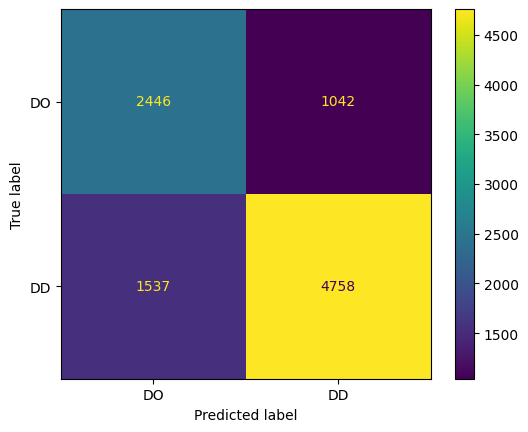

Confusion matrix for epoch 1:


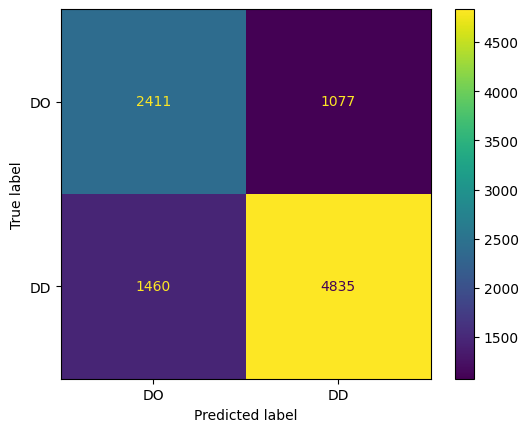

Confusion matrix for epoch 2:


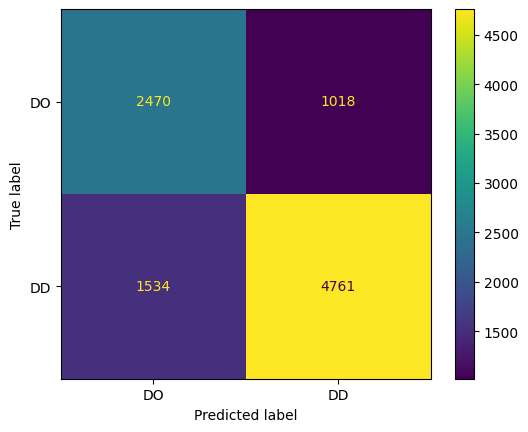

Confusion matrix for epoch 3:


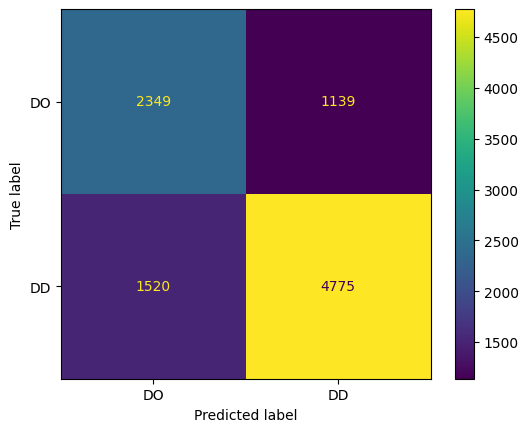

In [ ]:
## Fine tuning for sequence classification

# Clear out GPU cache
torch.cuda.empty_cache()

# Create datasets for training and testing
train_dataset = SequenceDataset(train_df)
test_dataset = SequenceDataset(test_df)

# Compute class weights for imbalanced datasets
all_labels = train_df['label'].values
num_labels = np.unique(all_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=num_labels, y=all_labels)

# Using sampler to to control class representation
#sampler = WeightedRandomSampler(weights=class_weights, num_samples=len(train_dataset), replacement=True)


# Create DataLoaders for training and testing
#train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler, collate_fn=collate_fn, pin_memory=True,num_workers=2)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn, pin_memory=True,num_workers=2,persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn, pin_memory=True,num_workers=2, persistent_workers=True)

# Load the ESMC base model from pretrained using the custom class
base_esmc_model = ESMC.from_pretrained("esmc_600m")

# Define the LoRA configuration
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules="all-linear",
    lora_dropout=0.1,
    bias="none",
    use_rslora=True,
)

# Use get_peft_model instead of inject_adapter_in_model
base_esmc_model = get_peft_model(base_esmc_model, lora_config)

# Instantiate the ESMC_SequenceClassification model
model = ESMC_SequenceClassification(num_labels=2, model= base_esmc_model, num_features=1152, dropout=0.5)

# Print the trainable parameters
print_trainable_parameters(model)

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Modify class weights for imbalanced datasets
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = bnb.optim.Adam8bit(model.parameters(), lr=3e-5)

# Setup training and save the results
results = train(model=model,
                train_dataloader=train_loader,
                test_dataloader=test_loader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=4,
                device=device,
                accumulation_steps=4)
results = pd.DataFrame(results)
results.to_csv("training_logs_ESMC600_sequence_classification_fine_tuned.csv")

# Save the model state
PATH = "ESMC600_sequence_classification_idrs_model_fine_tuned.pth"
torch.save(model.state_dict(), PATH)

# Plot the confusion matrix
for i in range(len(results["test_confusion_matrix"])):
    print(f"Confusion matrix for epoch {i}:")
    #print(f"Confusion matrix for epoch {i+1}:")
    cm = results["test_confusion_matrix"][i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.array(["DO","DD"]))
    disp.plot()
    plt.show()

In [ ]:
## Saving checpoint for further training

# Define path and checkpoint content
PATH = "my_model_checkpoint.pth"
checkpoint = {
    'epoch': 4,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': 0.100647
}

# Save the checkpoint
torch.save(checkpoint, PATH)

trainable params: 2670594 || all params: 577707586 || trainable%: 0.46
Resuming training from epoch 5


Processing batches for testing: 100%|██████████| 1223/1223 [11:00<00:00,  1.85it/s]


,Epoch,train_loss,train_accuracy,test_loss,test_accuracy,test_f1,test_precision,test_recall,test_confusion_matrix
0,1,0.073046,0.882974,0.71575,0.719922,0.720205,0.720503,0.719922,"[[2134, 1354], [1386, 4909]]"


Confusion matrix for epoch 0:


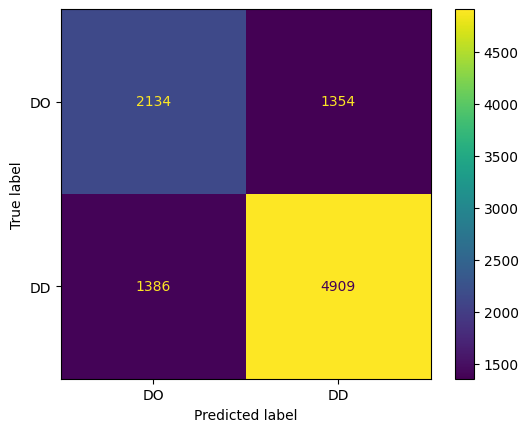

In [11]:
## Extend the training for further epoch based on saved checkpoint

PATH = "my_model_checkpoint.pth"

# Create datasets for training and testing
train_dataset = SequenceDataset(train_df)
test_dataset = SequenceDataset(test_df)

# Compute class weights for imbalanced datasets
all_labels = train_df['label'].values
num_labels = np.unique(all_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=num_labels, y=all_labels)

# Create DataLoaders for training and testing
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn, pin_memory=True,num_workers=2,persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn, pin_memory=True,num_workers=2, persistent_workers=True)

# Load the ESMC base model from pretrained using the custom class
base_esmc_model = ESMC.from_pretrained("esmc_600m")

# Define the LoRA configuration
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    target_modules="all-linear",
    lora_dropout=0.1,
    bias="none",
    use_rslora=True,
)

# Use get_peft_model instead of inject_adapter_in_model
base_esmc_model = get_peft_model(base_esmc_model, lora_config)

# Instantiate the ESMC_SequenceClassification model
model = ESMC_SequenceClassification(num_labels=2, model= base_esmc_model, num_features=1152, dropout=0.5)

# Print the trainable parameters
print_trainable_parameters(model)

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Modify class weights for imbalanced datasets
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = bnb.optim.Adam8bit(model.parameters(), lr=3e-5)

# Load the saved checkpoint
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']

# Restart training
print(f"Resuming training from epoch {epoch + 1}")
results = train(model=model,
                train_dataloader=train_loader,
                test_dataloader=test_loader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=1,
                device=device,
                accumulation_steps=4)
results = pd.DataFrame(results)
results.to_csv("training_logs_ESMC600_sequence_classification_fine_tuned_extended.csv")

# Save the model state
PATH = "ESMC600_sequence_classification_idrs_model_fine_tuned_extended.pth"
torch.save(model.state_dict(), PATH)

# Plot the confusion matrix
for i in range(len(results["test_confusion_matrix"])):
    print(f"Confusion matrix for epoch {i}:")
    #print(f"Confusion matrix for epoch {epoch + i}:")
    cm = results["test_confusion_matrix"][i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.array(["DO","DD"]))
    disp.plot()
    plt.show()
